In [48]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
import seaborn as sns

In [4]:
data = pd.read_csv('winequality-red.csv')

In [5]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [9]:
data.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [12]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [15]:
data['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [22]:
data['Target'] = data['quality'].apply(lambda x : 1 if x>=7 else 0 )

In [26]:
data.shape

(1599, 13)

In [47]:
data['Target'].value_counts()

Target
0    1382
1     217
Name: count, dtype: int64

In [41]:
X = data.drop(['Target', ],axis=1)
Y = data['Target']

In [32]:
data = data.drop('quality', axis =1)

<Axes: >

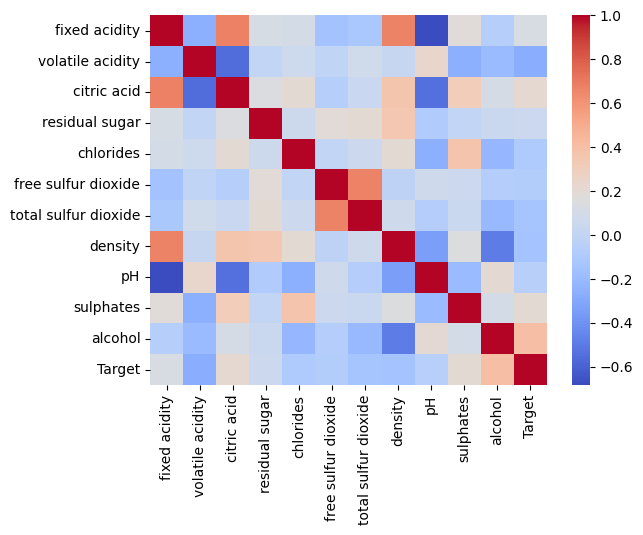

In [36]:
sns.heatmap(data.corr(), cmap= 'cool')

In [39]:
data.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Target
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.120061
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.270712
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.214716
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.047779
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.097308
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.071747
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.139517
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.150460
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057283
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.199485


In [43]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.3 )

In [44]:
classifier = DecisionTreeClassifier()

In [45]:
classifier.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [46]:
Y_pred = classifier.predict(X_test)

In [49]:
accuracy = accuracy_score(Y_pred, Y_test)

In [50]:
accuracy

0.8666666666666667

In [52]:
report = classification_report(Y_pred, Y_test)
print(report)

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       423
           1       0.45      0.51      0.48        57

    accuracy                           0.87       480
   macro avg       0.69      0.71      0.70       480
weighted avg       0.87      0.87      0.87       480



In [55]:
parameters = {
    'criterion':['gini', 'entropy','log_loss'],
    'max_depth': [2,4,8,12], 
    'min_samples_leaf':[1,2,3],
    'max_features':[2,4,3]
}

In [56]:
cv = GridSearchCV(classifier, param_grid=parameters, cv = 5)

In [57]:
cv.fit(X_train,Y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [2, 4, ...], 'max_features': [2, 4, ...], 'min_samples_leaf': [1, 2, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [58]:
cv.best_params_

{'criterion': 'gini', 'max_depth': 8, 'max_features': 4, 'min_samples_leaf': 1}

In [59]:
cv.best_score_

np.float64(0.891872197309417)

In [61]:
cv.classes_

array([0, 1])

In [64]:
tuned_model = DecisionTreeClassifier(criterion = 'gini', max_depth= 8, max_features= 4, min_samples_leaf= 1)

In [65]:
tuned_model.fit(X_train, Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,4
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [66]:
Y_tuned = tuned_model.predict(X_test)

In [68]:
print(classification_report(Y_tuned,Y_test))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93       432
           1       0.42      0.56      0.48        48

    accuracy                           0.88       480
   macro avg       0.68      0.74      0.70       480
weighted avg       0.90      0.88      0.89       480

